In [51]:
import numpy as np
import qiskit as q
from qiskit import QuantumCircuit, transpile, assemble, QuantumRegister, AncillaRegister
from qiskit_aer import AerSimulator

from qiskit.quantum_info.operators import Operator
from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex
import matplotlib as mpl
import matplotlib.pyplot as plt

from qiskit_ibm_runtime.fake_provider import FakeBrisbane
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.visualization import plot_histogram, plot_state_city

In [52]:
#parameters

M = 64 # lattices

w1 = 0.5 
w2 = 0.5 
e1 = 1   ##right
e2 = -1  ##left
cs = 1   ##speed of sound
u = 0.2  ##advection 


x = w1*(1+e1*u/cs**2)
y = w2*(1+e2*u/cs**2)

lambda1 = np.arccos(x)
lambda2 = np.arccos(y)

x,y

(0.6, 0.4)

In [53]:
def oneStep(lambda1,lambda2):
    
    #initializing
    n = int(np.log2(2*M))
    q = QuantumRegister(n,'q')
    a = AncillaRegister(1,'a')

    qc = QuantumCircuit(q)
    qc.add_register(a)
    
    
    qc.barrier()

    #collisions
    def createC(lambda1, lambda2, isC1 = True):
    
        if not isC1:
            lambda1 *= -1
            lambda2 *= -1


        qc=QuantumCircuit(2)

        #phase1 -> x -> phase1 -> x -----ctrl=0
        qc.cp(lambda1, 0 ,1 , ctrl_state = 0)
        qc.cx(0, 1, ctrl_state = 0)
        qc.cp(lambda1, 0, 1, ctrl_state = 0)
        qc.cx(0, 1, ctrl_state = 0)

        #phase2 -> x -> phase2 -> x -----ctrl=1 is default
        qc.cp(lambda2, 0, 1, ctrl_state = 1)
        qc.cx(0, 1)
        qc.cp(lambda2, 0, 1, ctrl_state = 1)
        qc.cx(0, 1)

        return qc
    
    C1 = createC(lambda1, lambda2, True)
    c1gate = C1.to_gate(label = 'c1')
    C2 = createC(lambda1, lambda2, False)
    c2gate = C2.to_gate(label = 'c2')
    
    
    #####adding steps to circuit
    qc.h(a)
    qc.append(c1gate.control(1, ctrl_state = 0),[a,n-1,0])
    qc.append(c2gate.control(1, ctrl_state = 1),[a,n-1,0])
    qc.h(a)
    qc.draw()
    
    
    
    #propagation
    def rshift(n):
        circ = QuantumCircuit(n-1)
        for i in range(n-1):
            if i == n-2:
                circ.x(i)
            else:
                circ.mcx(list(range(i+1,n-1)), i)
        return circ

    def lshift(n):
        circ = QuantumCircuit(n-1)
        for i in reversed(range(n-1)):
            if i == n-2:
                circ.x(i)
            else:
                circ.mcx(list(range(i+1,n-1)), i)
        return circ
    
    qc.barrier()
    R = rshift(n).to_gate(label = "R").control(1, ctrl_state = 0)#.control(1, ctrl_state = 0)
    L = lshift(n).to_gate(label = "L").control(1, ctrl_state = 1)#.control(1, ctrl_state = 0)
    
    cbits = [n-1]
    cbits.extend([i for i in range(n-2,-1,-1)])  

    qc.append(R,cbits)
    qc.append(L,cbits)

    
    ######################### macros
    qc.swap(a,n-1)
    qc.h(a)
#     qc.h(n-1)

    return qc

In [54]:
qc = oneStep(np.arccos(x),np.arccos(y))
# the following line throws a no attribute error
# qc.draw().savefig('qd1q2.pdf') # saves the circuit in a file called qd1q2
qc.draw() # draws circuit

░      ┌─────┐┌─────┐      ░ ┌────┐┌────┐        
q_0: ─░──────┤1    ├┤1    ├──────░─┤5   ├┤5   ├────────
      ░      │     ││     │      ░ │    ││    │        
q_1: ─░──────┤     ├┤     ├──────░─┤4   ├┤4   ├────────
      ░      │     ││     │      ░ │    ││    │        
q_2: ─░──────┤     ├┤     ├──────░─┤3   ├┤3   ├────────
      ░      │     ││     │      ░ │  R ││  L │        
q_3: ─░──────┤  c1 ├┤  c2 ├──────░─┤2   ├┤2   ├────────
      ░      │     ││     │      ░ │    ││    │        
q_4: ─░──────┤     ├┤     ├──────░─┤1   ├┤1   ├────────
      ░      │     ││     │      ░ │    ││    │        
q_5: ─░──────┤     ├┤     ├──────░─┤0   ├┤0   ├────────
      ░      │     ││     │      ░ └─┬──┘└─┬──┘        
q_6: ─░──────┤0    ├┤0    ├──────░───o─────■────X──────
      ░ ┌───┐└──┬──┘└──┬──┘┌───┐ ░              │ ┌───┐
  a: ─░─┤ H ├───o──────■───┤ H ├─░──────────────X─┤ H ├
      ░ └───┘              └───┘ ░                └───┘

In [55]:
#### initialState
initState = np.ones(M)/10  #0.1 everywhere
initState[12] = 0.2
nrm = np.linalg.norm(initState)
initState = np.concatenate((initState,initState))
#### statevector

SV = Statevector(initState/np.linalg.norm(initState)).expand([1,0])
initSV = SV #save for future reference


# Objective: simulate a single timestep on a simulator

In [56]:
# # prepare the initial quantum state
# circ = QuantumCircuit(qc.num_qubits)
# circ.prepare_state(SV)

In [57]:
# circ.append(qc, list(range(qc.num_qubits)))

In [58]:
# print(circ.depth())
# print(circ.num_qubits)

In [59]:
# circ_copy = circ.copy()
# circ_copy.measure_all()

In [60]:
# # if I recall correctly, FakeBrisbane() has 127 qubits
# # simulator = AerSimulator.from_backend(FakeBrisbane())
# simulator = AerSimulator()

In [61]:
# circ_copy = transpile(circ_copy, simulator)

In [62]:
# result = simulator.run(circ_copy, shots=100_000).result()
# counts = result.get_counts(circ)

In [63]:
# counts = counts.int_outcomes()

In [64]:
# keys = list(counts.keys())
# keys.sort()
# sorted_counts = {i: counts[i] for i in keys}

In [65]:
# sorted_counts

In [66]:
# plot_histogram(counts, title="D1Q2 Timestep = 1 Counts")

# Objective: simulate final state on simulator

In [67]:
def timestep(sv):
    return sv.evolve(qc)

def graph(sv, color = "red"):
    plt.plot(list(range(0,M,1)), np.array(sv)[:M:1],color)
    plt.plot(list(range(M,2*M,1)), np.array(sv)[M:2*M:1],color)
    plt.plot(list(range(2*M,3*M,1)), np.array(sv)[2*M:3*M:1],color)
    plt.plot(list(range(3*M,4*M,1)), np.array(sv)[3*M::1],color)
    
def hres(sv):
    plt.plot(list(range(0,M,1)), 2**(1)*nrm*np.array(sv)[:M:])
    plt.xlabel("Lattice site")
    plt.ylabel("Concentration")
def hres2(sv):
    plt.plot(list(range(0,M,1)), 2**(1)*nrm2*np.array(sv)[:M:])  
def reinit(sv):
    tmp = np.array(sv)[:M]
    tmp = np.concatenate((tmp,tmp))
    return Statevector(tmp/np.linalg.norm(tmp)).expand([1,0])

In [72]:
def simulate(sv, qc):
    simulator = AerSimulator()
    # simulator = AerSimulator()
    # prepare the state of the given state vector
    circ = QuantumCircuit(qc.num_qubits)
    circ.prepare_state(sv)
    circ.measure_all()

    circ = transpile(circ, simulator)
    result = simulator.run(circ, shots=1_000_000).result()
    counts = result.get_counts(circ)

    # sort counts
    keys = list(counts.keys())
    keys.sort()
    counts = {i: counts[i] for i in keys}
    return counts

In [69]:
# RESET
#### initialState
initState = np.ones(M)/10  #0.1 everywhere
initState[12] = 0.2
nrm = np.linalg.norm(initState)
initState = np.concatenate((initState,initState))
#### statevector

SV = Statevector(initState/np.linalg.norm(initState)).expand([1,0])
initSV = SV #save for future reference


In [70]:
def save_fig(counts, i):
    vals = np.array(list(counts.values()))
    vals = vals / np.linalg.norm(vals)  

    plt.xlabel("Lattice Site")
    plt.ylabel("Probability")
    plt.title(f"Distribution of Counts at t = {i}")

    plt.plot(list(range(0,M,1)), vals[:M:])
    plt.savefig(f'd1q2simulation/{i}.png')

    plt.close('all')
    

In [71]:
# hres(initSV)
# SAVE FIGURES
iterations = 51
for i in range(1, iterations):
    print(i)
    SV = timestep(SV)
    counts = simulate(SV, qc)
    save_fig(counts, i)
    SV = reinit(SV)

1


TypeError: AerSimulator.from_backend() missing 1 required positional argument: 'backend'

AttributeError: 'Figure' object has no attribute 'close'

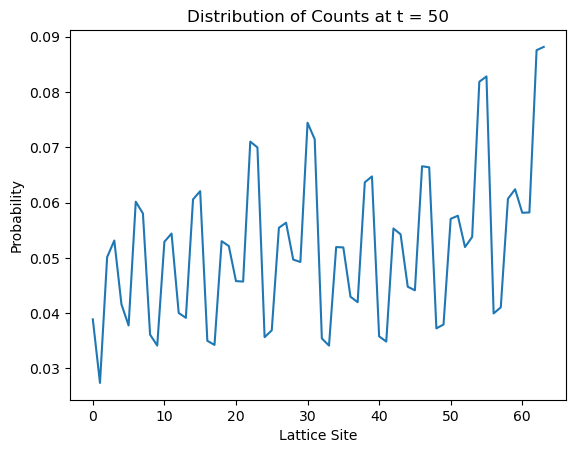

<Figure size 640x480 with 0 Axes>

In [48]:
# # hres(initSV)
# # Visualize only image at t = iteration
# for i in range(1,51):
#     SV = timestep(SV)
#     if i==50:
#         counts = simulate(SV, qc)
#         save_fig(counts, i)
#     np.savetxt('d1q2/'+str(i+1)+'.csv', np.real(2**(1)*nrm*np.array(SV)[:M:]), delimiter=',')
#     SV = reinit(SV)

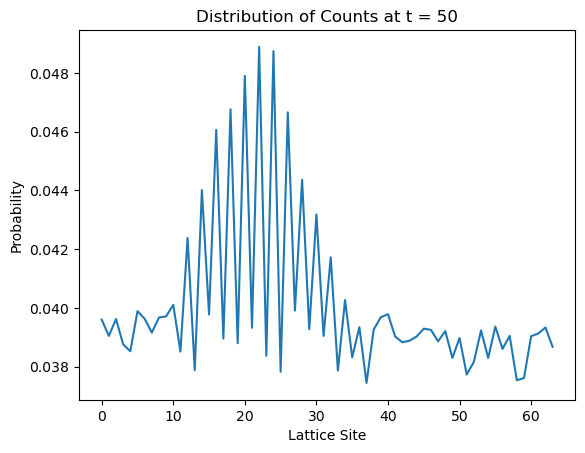

<Figure size 640x480 with 0 Axes>

In [23]:
save_fig(counts, 50)

/Users/melod/anaconda3/envs/qiskit1/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/melod/anaconda3/envs/qiskit1/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


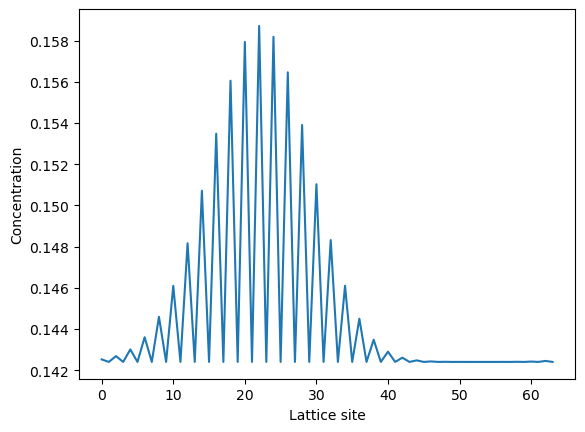

In [24]:
hres(SV)

In [25]:
# plt.plot(list(range(0,M,1)), 2**(1)*nrm*vals[:M:])
# plt.xlabel("Relative Probability")
# plt.ylabel("Lattice Site")

In [26]:
# #### initialState
# x0 = 32
# sig = 4/np.sqrt(2)
# tmar = [-(pos-x0)**2/(2*sig**2) for pos in range(64)]
# tmar = np.exp(tmar)
# nrm2 = np.linalg.norm(tmar)
# tmar = np.concatenate((tmar,tmar))
# #### statevector

# SV2 = Statevector(tmar/np.linalg.norm(tmar)).expand([1,0])
# initSV2 = SV2 #save for future reference

In [27]:
# hres(initSV2)
# for i in range(1,51):
#     SV2 = timestep(SV2)
#     if i%10==0:
#         hres2(SV2)
#     SV2 = reinit(SV2)